# Data Visualization - Part 1: Visualization Basics
```
Course: ENV 700 - Environmental Data Exploration
Authors: John Fay & Luana Lima
```

## Overview

Effective data visualization depends on purposeful choices about graph types. The ideal graph type depends on the type of data and the message the visualizer desires to communicate. The best visualizations are clear and simple. A good resource for data visualization is [Data to Viz](https://www.data-to-viz.com/), which includes both a decision tree for visualization types and explanation pages for each type of data, including links to Python resources to create them. Take a few minutes to explore this website.

In this lesson, we introduce the [Seaborn package](https://seaborn.pydata.org/index.html). Seaborn is a high-level visualization library built on top of [Matplotlib](https://matplotlib.org/). It is tightly integrated with Pandas DataFrames and allows you to map dataframe columns to visual aesthetics (`hue`, `size`, `style`) automatically without writing loops. 

We'll use Seaborn to visualize processed data from both the EPA AQS and the NTL LTER Peter and Paul Lakes datasets. 

## Learning objectives

By the end of this lesson, you should be able to:

1. Apply a decision tree framework for appropriate graphing methods.
1. Navigate the Seaborn documentation on plotting functions and Seaborn's basic plotting syntax.
1. Articulate the relationship between Pandas, Seaborn, and Matplotlib. 
1. Wrangle data into long formats for easier plotting of multiple attributes.
1. Plot distributions using Seaborn's `displot()` function.
1. Plot categories using Seaborn's `catplot()` function. 
1. Plot relationships using Seaborn's `relplot` function. 

---
## Visualization: Background
- **What is Data Visualization** [[source](https://www.geeksforgeeks.org/data-visualization/data-visualization-and-its-importance/)]
    - Turning data into visual formats: charts, graphs, and maps
    - Makes complex data easy to understand at a glance
    - Helps identify trends, patterns, and insights

- **The Power of Data Visualization** [Gapminder visualization](https://www.gapminder.org/tools/#$chart-type=bubbles&url=v2)
    - Faster insights 
    - Better decision making
    - Simplifies complex data
    - Improved communication
    - Time efficiency

- **The Curse of Data Visualizaion** <https://viz.wtf/>
    - Misleading interpretations
    - Oversimplification
    - Congitive bias, cherry picking
    - False precision, over confidence in source data
    - Confuse causation with correlation [[example](https://www.tylervigen.com/spurious-correlations)]

- **Basic principles**
    - Select the appropriate chart type <https://www.data-to-viz.com/>
    - Think about what you are trying to show
    - Simpler is better
    - Keep your audience in mind

---
## Creating Data Visualizations in Python
- Python provides many packages for plotting: [Link](https://geo-python-site.readthedocs.io/en/lih/lessons/L7/python-plotting.html)
- `Matplotlib`: "the grand old man of Python plotting" 
    - [Examples](https://matplotlib.org/stable/gallery/index.html#lines-bars-and-markers)
    - 👍Powerful, versitile
    - 👎Confusing! 
- `Seaborn`: A simpler interface to Matplotlib: <https://seaborn.pydata.org/>
    - 👍Simplifies many of the confusing bits of Matplotlib
    - 👍Allows access to Matplotlib back end -- for additional control
    - 👎Still a bit confusing -- at first
- The "Grammar of Graphics" 
    - Create a "canvas": the **figure**
    - Specify the type of plot: the **axes**
    - Apply **aesthetics**: how data appear along the the axes, color, shape
    - Additional tweaks to **style** the plot: axis labels, titles, etc.
- Seaborn offers useful defaults - **themes** - to simplify these tasks
    - Groups plot types into 3 categories: *Distributions*, *Categories*, *Relationships*
    - Can do more, but this is a great start...


---
## 🚀Diving In: Set up your session
* Perhaps the best way to learn how to visualize data in Python is to do it! 
* We'll use Seaborn to visualise two datasets: 
    - `NTL-LTER_Lake_Chemistry_Nutrients_PeterPaul_Processed.csv`
    - `EPAair_O3_PM25_NC1819_Processed.csv`
* Start by configuring our workspace and importing the datasets into dataframes.
* Also transform these data into different formats (wide/long) for different plotting needs.

#### Packages

In [2]:
# Packages
from pathlib import Path
import pandas as pd
import seaborn as sns     
import calendar

#### Paths

In [2]:
# Paths
root_fldr = Path.cwd().parent
raw_fldr = root_fldr / "data" / "raw"
processed_fldr = root_fldr / "data" / "Processed_KEY"

#### Data Import

In [3]:
# Data import: Peter & Paul Lakes 
PeterPaul_chem_nutrients = pd.read_csv(
    processed_fldr/'NTL-LTER_Lake_Chemistry_Nutrients_PeterPaul_Processed.csv',
    parse_dates=['sampledate']
)
PeterPaul_chem_nutrients.head(2)

,lakename,year4,daynum,month,sampledate,depth,temperature_C,dissolvedOxygen,irradianceWater,irradianceDeck,tn_ug,tp_ug,nh34,no23,po4
0,Paul Lake,1984,148,5,1984-05-27,0.00,14.5,9.5,1750.0,1620.0,NaN,NaN,NaN,NaN,NaN
1,Paul Lake,1984,148,5,1984-05-27,0.25,NaN,NaN,1550.0,1620.0,NaN,NaN,NaN,NaN,NaN


In [4]:
# Data import: EPA AQS data
EPAair = pd.read_csv(
    processed_fldr/'EPAair_O3_PM25_NC1819_Processed.csv',
    parse_dates=['Date']
)
EPAair.head(2)

,Unnamed: 0,Date,Site.Name,COUNTY,mean_Lat,mean_Lng,Month,Year,PM2.5,Ozone
0,1,2018-01-01,Bryson City,Swain,35.434767,-83.442133,1,2018,35.0,NaN
1,2,2018-01-01,Castle Hayne,New Hanover,34.364167,-77.838611,1,2018,13.0,NaN


#### Data Wrangling
If we have multiple related attributes we want to visualize on the same plot, then "melting" the dataframe into a long format can make plotting easier. Here, we'll melt the nutrient data, taking the `tp_ug`, `tn_ug`, `nh34`, `no23`, and `po4` columns and transforming them into columns of "`nutrient`" and "`concentration`".

In [5]:
#Create a long format version of PeterPaul_chem_nutrients data
PeterPaul_chem_nutrients_long = PeterPaul_chem_nutrients.melt(
    id_vars = ['lakename','year4','month','sampledate','depth'],
    value_vars=['tn_ug','tp_ug','nh34','no23','po4'],
    var_name='nutrient',
    value_name='concentration'
).dropna(subset='concentration')
PeterPaul_chem_nutrients_long.head(2)

,lakename,year4,month,sampledate,depth,nutrient,concentration
5273,Paul Lake,1991,5,1991-05-20,0.0,tn_ug,538.0
5281,Paul Lake,1991,5,1991-05-20,3.0,tn_ug,453.0


#### 🔥*New Concept*🔥 - Categories & Labels
* We've introduced the *categorical* data type already
* Panda's [`Categorical()`](https://pandas.pydata.org/docs/reference/api/pandas.Categorical.html) converts a variable into a categorical data type *and* allows us to explicitly define its possible levels (categories) and their sequence. This is especially useful when the natural order of the categories—such as Jan through Dec—differs from alphabetical order.
* Here, we also make use of Python's [`calendar`](https://docs.python.org/3/library/calendar.html) package which provides an easy way to create a list of calendar abbreviations. 

In [6]:
#Create a month category with levels for all months
EPAair['month_abb'] = pd.Categorical(
    values=EPAair['Date'].dt.month_name().str[:3],
    categories=calendar.month_abbr[1:]
)

In [7]:
#Do the same for PeterPaul_chem_nutrients
PeterPaul_chem_nutrients['month_abb'] = pd.Categorical(
    values=PeterPaul_chem_nutrients['sampledate'].dt.month_name().str[:3],
    categories=calendar.month_abbr[1:]
)

In [8]:
#Create a depth class for NTL Data
def depth_class(depth):
    if depth==0: return 'surface'
    elif depth <= 10: return '1-10 m'
    elif depth <= 15: return '11-15 m'
    elif depth <= 20: return '16-20 m'
    else: return '> 20m'

#Old approach - no categories
PeterPaul_chem_nutrients['depth_class'] = PeterPaul_chem_nutrients['depth'].map(depth_class)

In [9]:
#Better approach - with categories & ordered labels
depth_levels = [
    'surface',
    '1-10 m',
    '11-15 m',
    '16-20 m',
    '> 20 m'
]
PeterPaul_chem_nutrients['depth_class'] = pd.Categorical(
    PeterPaul_chem_nutrients['depth'].map(depth_class),
    categories=depth_levels,
    ordered=True
)

>🔥 Pandas has a [`cut()`](https://pandas.pydata.org/docs/reference/api/pandas.cut.html) function that handles this process more elegantly, but we are learning enough as it is, and our approach works fine. 
```python
PeterPaul_chem_nutrients['depth_class'] = pd.cut(
    PeterPaul_chem_nutrients['depth'],
    bins=[-1, 0, 10, 15, 20, float('inf')],
    labels=['surface', '1-10 m', '11-15 m', '16-20 m', '> 20 m']
)
```

---
## 🛟Seaborn - a quick overview

Seaborn has a [hierarchical structure of plotting functions](https://seaborn.pydata.org/tutorial/function_overview.html#figure-level-vs-axes-level-functions). 

At the top of the hierarchy are commands for plotting **distributions** (`displot()`), **categories** (`catplot()`) and **relationships** (`relplot()`). Each of these plotting functions as a number of plotting sub-types that we will explore. We will also examine Seaborn's consistent command structure:

```python
sns.plot_function(
    data=df, 
    x="column_for_x", 
    y="column_for_y")
```

* The above statement creates and plots a **figure** displaying data on a pair of **axes**, X and Y. 
* How the data are displayed is controlled by the **plot *kind***.
* **Additional parameters** are available, depending on the kind of plot selected.

We'll begin by revisiting the plots we create in our Data Exploration lesson where we explore the distribution of data in our dataframe. 

---
## 📶 [Visualizing Distributions of Data](https://seaborn.pydata.org/tutorial/distributions.html)
* Use the `displot()` function to display distributions of data.
* The default plot type is a [histogram](https://seaborn.pydata.org/tutorial/distributions.html#plotting-univariate-histograms), but others include: [kernel-density estimate](https://seaborn.pydata.org/tutorial/distributions.html#kernel-density-estimation) (*kde*) and [empirical cumulative distribution](https://seaborn.pydata.org/tutorial/distributions.html#empirical-cumulative-distributions) (*ecdf*) plots. 

### Basic Distribution Plot:  Total Phosphorous
* The basic syntax is `sns.distplot(data=df, x="column_for_x")`
* Below we'll plot the distribution of `tp_ug` values in Peter and Paul Lakes using a histogram.

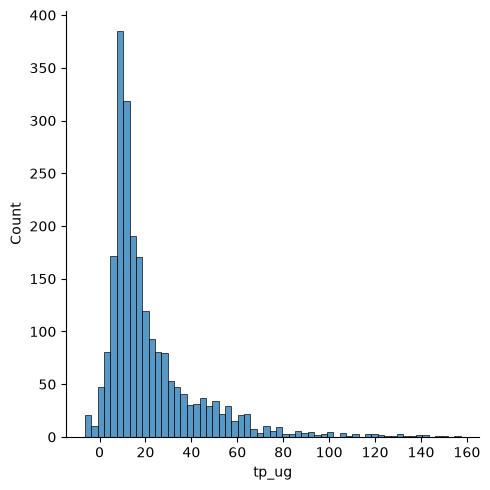

In [10]:
sns.displot(
    data=PeterPaul_chem_nutrients,
    x='tp_ug'
);

This is the most basic format. Consult the documentation on the [`histplot()`](https://seaborn.pydata.org/generated/seaborn.histplot.html#seaborn.histplot) for parameters you can change. 

##### 👉Things to try:
* Change number of bins.
* Change bin width.
* Set `element` to be "poly" or "step".
* Set `fill` to be False.
* Set `kde` to be True.
* Set `color` to be "r". (See [this page](https://matplotlib.org/stable/users/explain/colors/colors.html#specifying-colors) for other color options.)
* Set `height` to be 3.
* Set `aspect` to be 2.

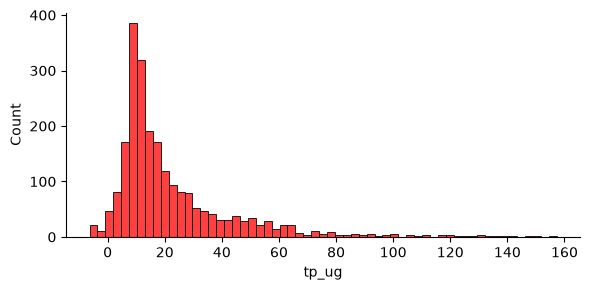

In [19]:
sns.displot(
    data=PeterPaul_chem_nutrients,
    x='tp_ug',
    #bins=30,
    #binwidth=10,
    #element='poly', fill=False,
    #kde=True,
    color='r',
    height=3,
    aspect=2
);

#### Distributions across groups
* We can use color, specifically ***hue***, to distinguish distributions among groups of data.

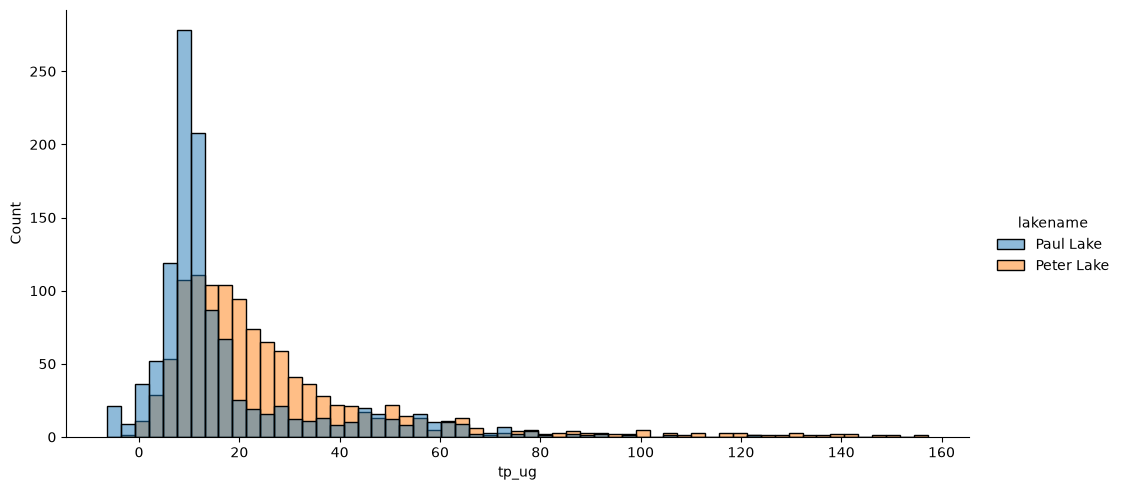

In [20]:
sns.displot(
    data=PeterPaul_chem_nutrients,
    x='tp_ug',
    hue='lakename',
    aspect=2
);

#### 👉Things to try:
The default layers one distribution on the other, which isn't ideal. To fix it, we can either move from bars to lines or re-align the bars.
* *[Option 1]* Switch the bars to lines:
    - Add `element='poly'` to swtich from bars to polygons
    - Add `fill=False` to disable filling the area
* *[Option 2a]*  Align bars for the different groups to be side by side:
    - Set bins to 10 (to illustrate the effect more clearly)
    - Add `multiple='dodge'`
* *[Option 2b]* Stack bars:
    - Add `multiple='stack'`

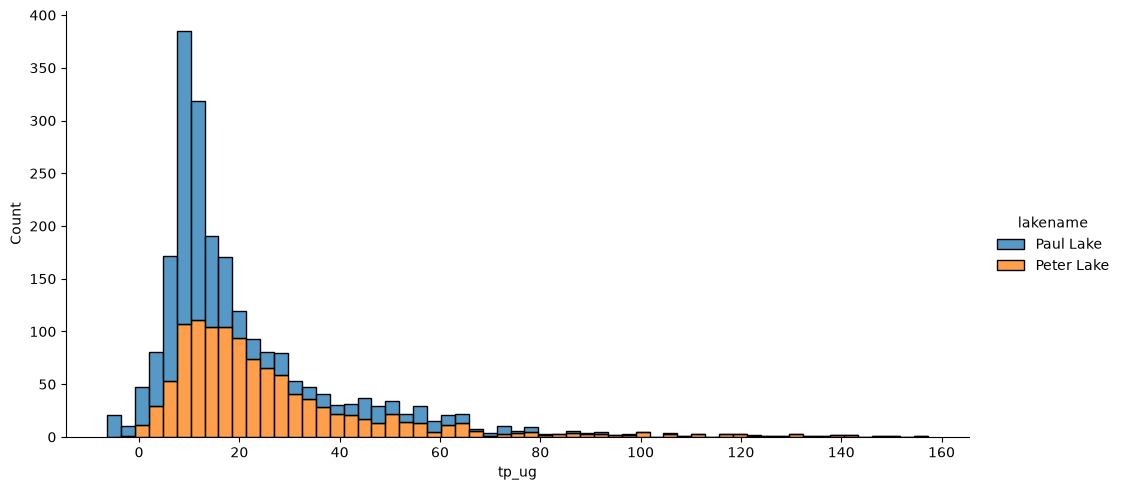

In [23]:
sns.displot(
    data=PeterPaul_chem_nutrients,
    x='tp_ug',
    hue='lakename',
    aspect=2,
    #element='poly', fill=False,  #<- Option 1  
    #multiple='dodge'#, bins=10,   #<- Option 2a
    multiple='stack',# bins=10,   #<- Option 2a
);

### Other Distribution Plots
The `displot()` function can create plots other than the default histogram plots, accomplished by setting the `kind` parameter. 

#### [Kernel Density Estimate Plot](https://seaborn.pydata.org/generated/seaborn.kdeplot.html)
* Figure: [How kernels are made](https://people.duke.edu/~jpfay/ENV700/kde_plot_generation.png)

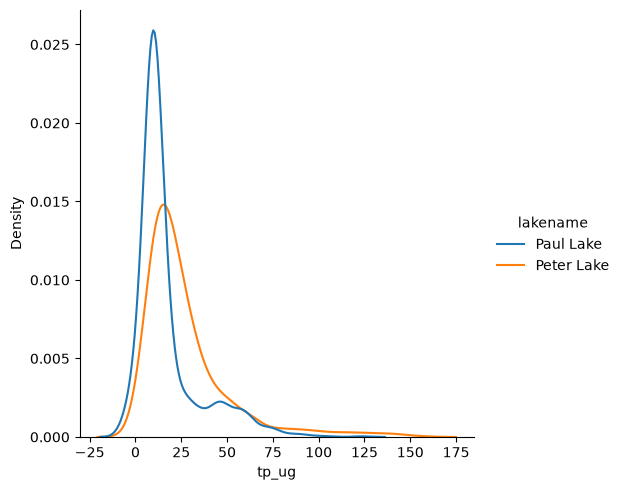

In [25]:
#KDE Plot
sns.displot(
    data=PeterPaul_chem_nutrients,
    x='tp_ug',
    kind='kde',
    hue='lakename'
);

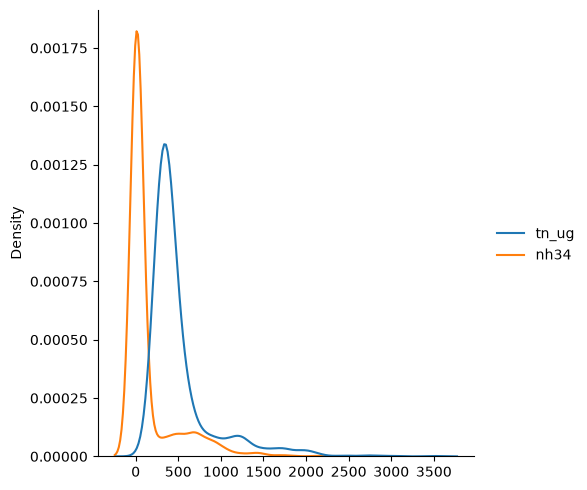

In [26]:
#KDE Plot - two variables (wide format)
sns.displot(
    data=PeterPaul_chem_nutrients[['tn_ug','nh34']],
    kind='kde',
);

>👉**Choose a KDE plot when you want to emphasize the overall shape of a distribution rather than the individual bin counts.**
>
>*A KDE plot:*
> - Shows a smooth estimate of the data’s probability distribution.
> - Avoids the arbitrary appearance caused by choosing histogram bin widths and boundaries.
> - Makes it easier to compare distributions for multiple groups on the same axes.
> - Highlights features such as peaks, skewness, and possible multimodality.
>
>*A histogram is usually preferable when:*
> - You want to show the *actual* distribution of observations.
> - The sample size is small.
> - Exact counts or frequencies matter.
> - The variable is discrete or has many repeated values.
> - You want a more transparent, less model-dependent display.

#### *Advanced*: [Empirical Cumulative Distribution Function plots](https://seaborn.pydata.org/generated/seaborn.ecdfplot.html)

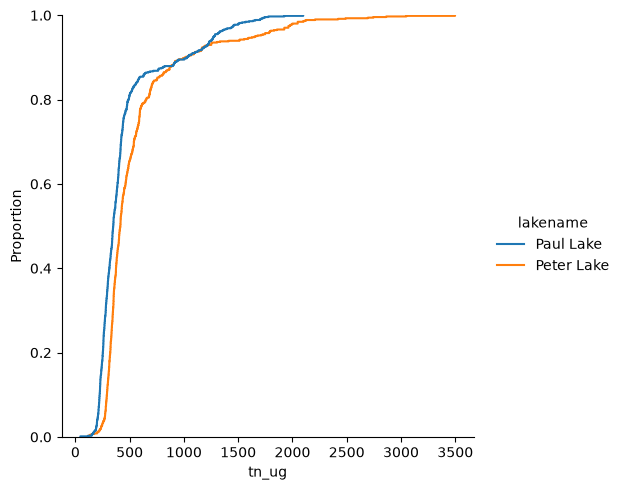

In [29]:
#ECDF Plot - measurements by month
sns.displot(
    data=PeterPaul_chem_nutrients,
    x='tn_ug',
    kind='ecdf',
    hue='lakename'
);

> 👉**Use an ECDF when you want to answer questions such as:**
> - What percentage of observations are below a threshold?
> - Which group generally has larger or smaller values?
> - How do the full distributions compare?
> - Where do the distributions differ, even beyond their averages?
> - What value represents the 50th, 90th, or 95th percentile?
>
> 👉**ECDF plots are particularly useful for comparing groups because they:**
> - do not require choosing histogram bins;
> - do not smooth the data like KDE plots;
> - display the entire distribution;
> - make thresholds and percentiles easy to interpret.

#### *Advanced*: Two-dimensional [Rug Plots](https://seaborn.pydata.org/generated/seaborn.rugplot.html)
* Adding a variable to the y-axis enables you to visualize co-incident distributions.
* A rug plot displays every individual observation as a small tick mark along an axis.
* Each tick represents one tp_ug observation. Where the ticks cluster, observations are more common; isolated ticks may indicate unusual values.

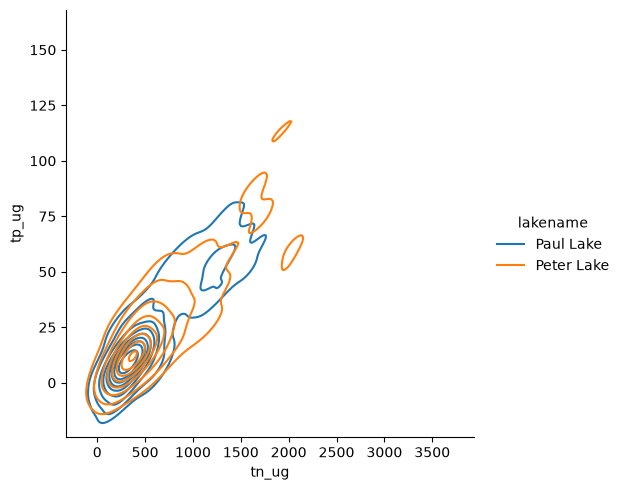

In [33]:
#Two-dimensional Rug Plot - measurements by month and year
sns.displot(
    data=PeterPaul_chem_nutrients,
    x='tn_ug',
    y='tp_ug',
    #rug='true',
    #binwidth=(50, 5),
    kind='kde',
    hue='lakename'
);

> 👉**A rug plot is useful when you want to:**
>
> * Show the individual observations behind a distribution;
> * Reveal clusters, gaps, or outliers;
> * Supplement a histogram or KDE plot;
> * Display observations for a small or moderate dataset.

### Beyond `displot()`

#### Plotting joint and marginal distributions with `jointplot()`

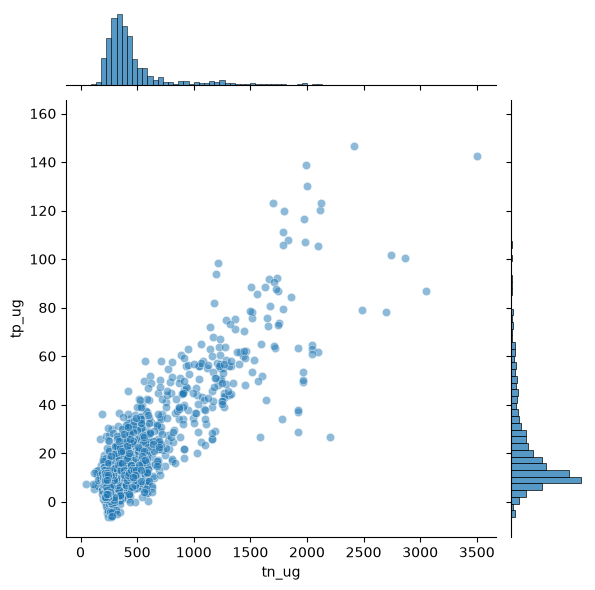

In [35]:
#Join plot showing relationships AND distributions
sns.jointplot(
    data=PeterPaul_chem_nutrients,
    x='tn_ug',
    y='tp_ug',
    #hue='lakename',
    alpha=0.5
);

#### Plotting many distributions with `pairplot()`

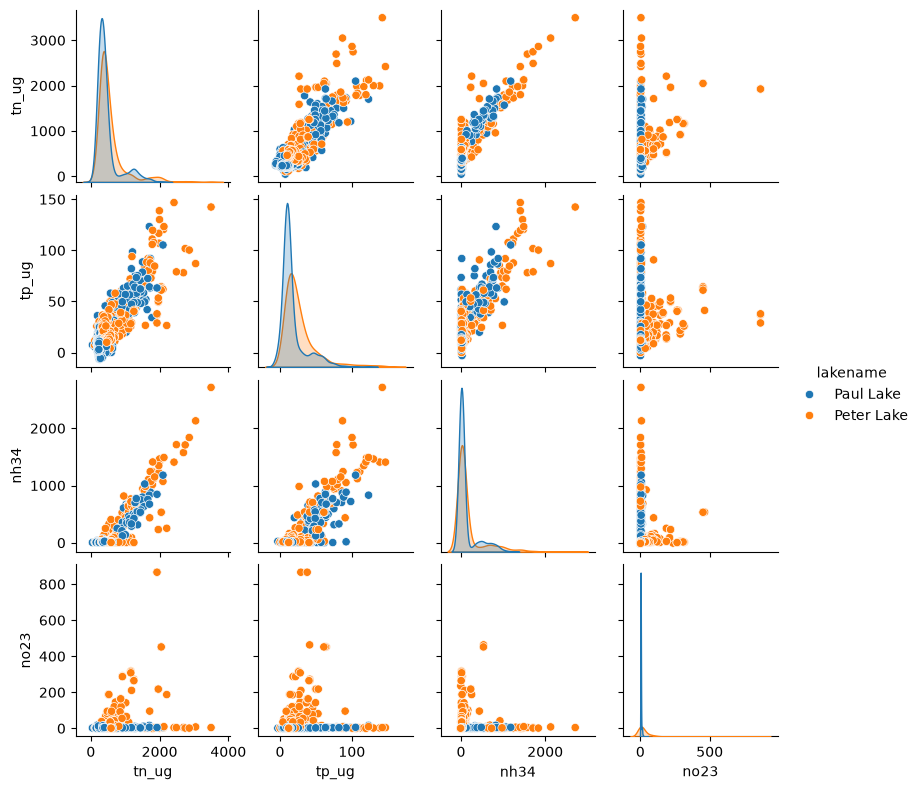

In [37]:
#Pairplot to examine multiple pair-wise relationships
sns.pairplot(
    data=PeterPaul_chem_nutrients,
    vars = ['tn_ug', 'tp_ug', 'nh34', 'no23'],
    height=2,
    hue='lakename'
);

---
## 📊 [Visualizing categorical data](https://seaborn.pydata.org/tutorial/categorical.html)
* Use the `catplot()` function to explore patterns among groups of data. This plot types provided by this function are prestented below.
* `stripplot()` is the default plot type.

### Categorical scatterplots
* [`stripplot()`](https://seaborn.pydata.org/generated/seaborn.stripplot.html) - Shows all observations, grouped by categories.
* [`swarmplot()`](https://seaborn.pydata.org/generated/seaborn.swarmplot.html) - Shows all observations without overlap (small datasets only).

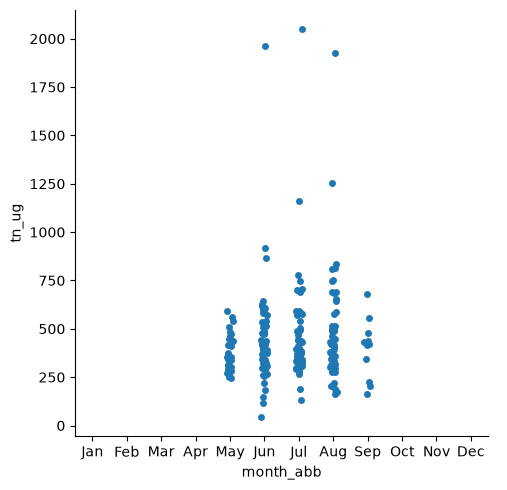

In [38]:
#Scatterplot
sns.catplot(
    data=PeterPaul_chem_nutrients.query('depth == 0'),
    x='month_abb',
    y='tn_ug'
);

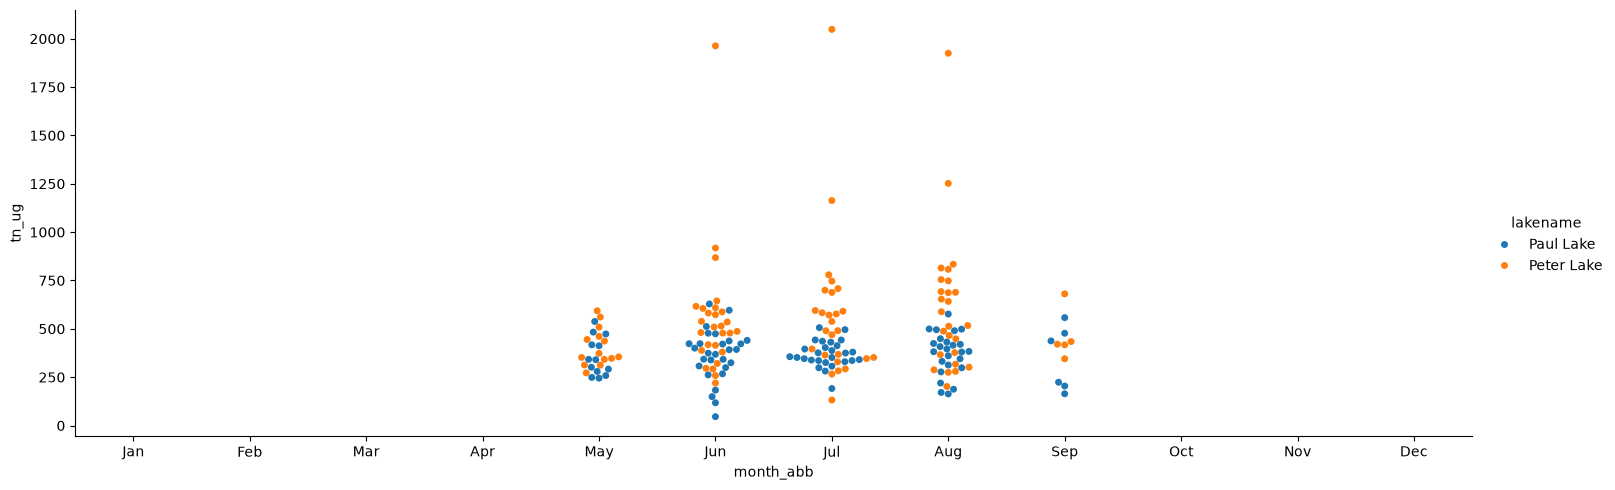

In [41]:
#Swarm plot
sns.catplot(
    data=PeterPaul_chem_nutrients.query('depth == 0'),
    x='month_abb',
    y='tn_ug',
    hue='lakename',
    kind='swarm',
    native_scale=True,
    aspect=3
);

### Comparing distributions
* [`boxplot()`](https://seaborn.pydata.org/generated/seaborn.boxplot.html) - Summarizes a distribution using the median, quartiles, whiskers, and potential outliers.
* [`violinplot()`](https://seaborn.pydata.org/generated/seaborn.violinplot.html) - Combines a box plot with a mirrored kernel density estimate to show the distribution's shape.
* [`boxenplot()`](https://seaborn.pydata.org/generated/seaborn.boxenplot.html) - Extends the box plot by displaying additional quantiles, especially in the tails.

In [3]:
#Box plot
sns.catplot(
    data=PeterPaul_chem_nutrients,
    x='month_abb',
    y='temperature_C',
    #hue='lakename',
    log_scale = True,
    kind='box',
    #kind='violin',
    #kind='boxen'
);

NameError: name 'PeterPaul_chem_nutrients' is not defined

### Estimating central tendencies
Does the distribution of data converge on a particular value?
* [`barplot()`](https://seaborn.pydata.org/generated/seaborn.barplot.html) - Compare values via aggregated statistic w/error bars.
* [`countplot()`](https://seaborn.pydata.org/generated/seaborn.countplot.html) - Count observations or frequencies (not aggregated).
* [`pointplot()`](https://seaborn.pydata.org/generated/seaborn.pointplot.html) - Compare estimated means, connecting by lines to show trends.

See also: [Seaborn's section on estimation and error bars](https://seaborn.pydata.org/tutorial/error_bars.html)

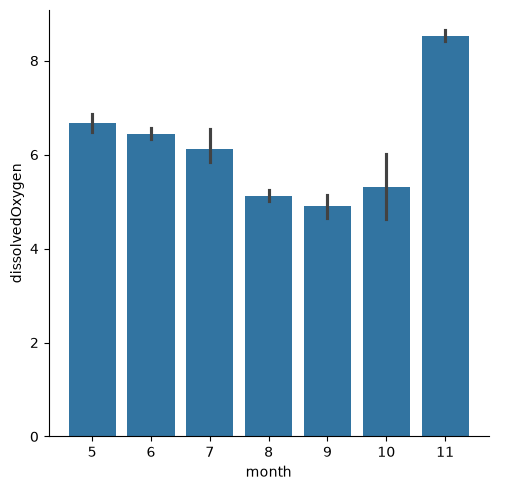

In [47]:
# Bar Plot
sns.catplot(
    data=PeterPaul_chem_nutrients,
    y ='dissolvedOxygen',
    x ='month',
    #hue='lakename',
    kind='bar',
    #errorbar='ci',
    native_scale=True,
    estimator='mean'
);

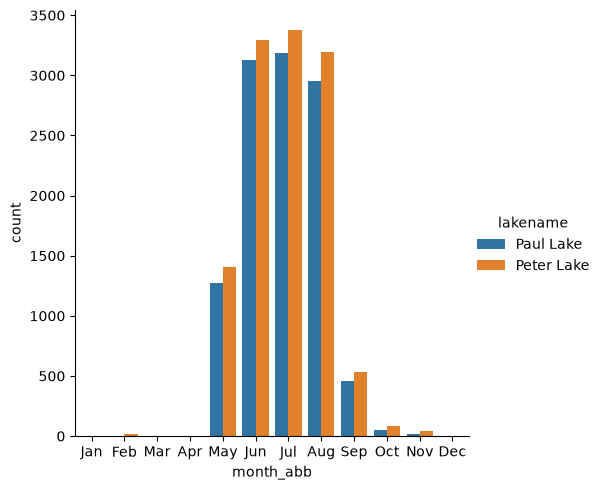

In [48]:
#Count plot
sns.catplot(
    data=PeterPaul_chem_nutrients,
    x='month_abb',
    hue='lakename',
    kind='count',
    #stat='percent'
    #dodge=False,
    #fill=False,
    #linewidth=0.5
);

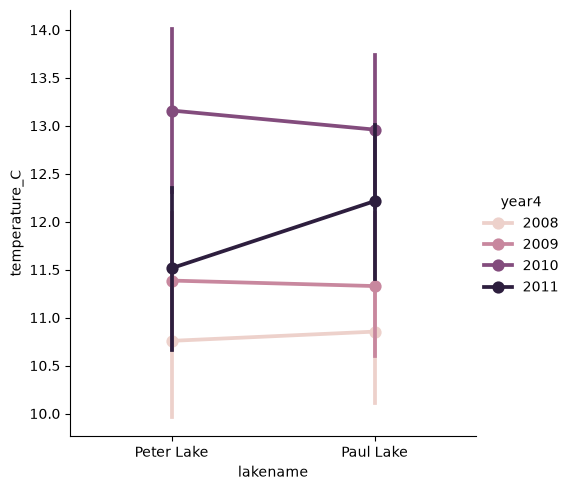

In [49]:
#Point plot
sns.catplot(
    data=PeterPaul_chem_nutrients.loc[PeterPaul_chem_nutrients['year4'].isin(range(2008,2012))],
    y='temperature_C',
    x ='lakename',
    hue='year4',
    kind='point',
    #palette='colorblind',
    #errorbar=None,
);

---
## 📈 [Visualizing Relationships](https://seaborn.pydata.org/tutorial/relational.html)

* Use `relplot()` to explore relationships among variables in the dataframe. 
* This is central to understanding pattersn, trends, and potential associations in data, how they interact. 
* `scatterplot()` is the default plot type.

### [Scatterplots](https://seaborn.pydata.org/generated/seaborn.scatterplot.html#seaborn.scatterplot)
* Display individual observations as points.
* Reveals relationships, clusters, and outliers.

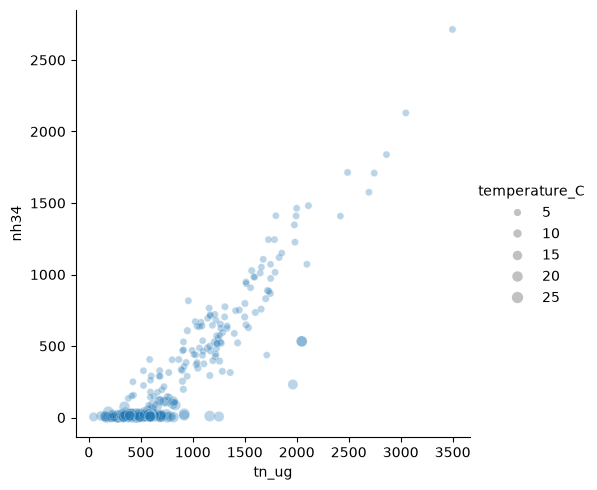

In [52]:
#Scatterplot
sns.relplot(
    data=PeterPaul_chem_nutrients,
    x='tn_ug',
    y='nh34',
    #hue='lakename',
    alpha=0.3,
    size='temperature_C'
);

#### Regressions
* `relplot()` will not compute regression lines
* `regplot()` and  `lmplot()` will

<Axes: xlabel='tn_ug', ylabel='nh34'>

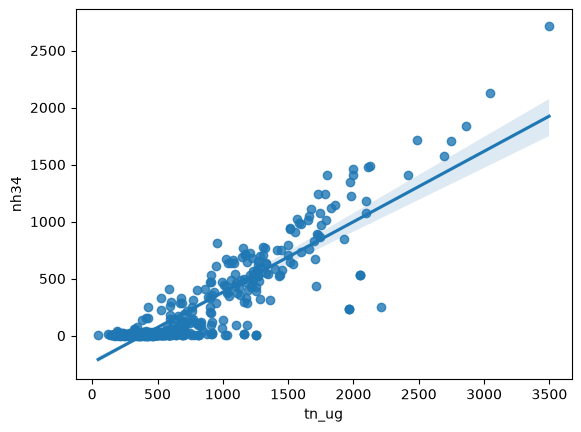

In [53]:
sns.regplot(
    data=PeterPaul_chem_nutrients,
    x='tn_ug',
    y='nh34'
)

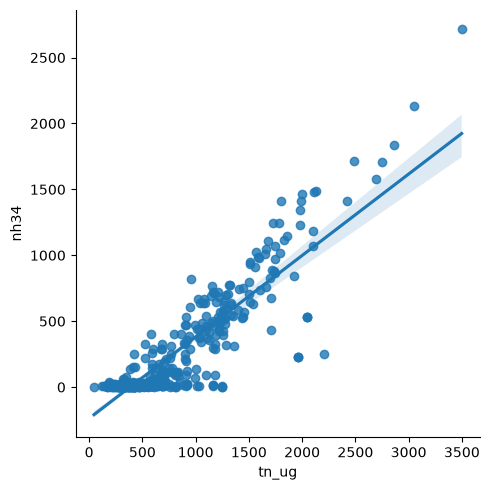

In [54]:
sns.lmplot(
    data=PeterPaul_chem_nutrients,
    x='tn_ug',
    y='nh34',
    #hue='lakename',
    #markers='.',
    #ci=None
);

### [Lineplots](https://seaborn.pydata.org/generated/seaborn.lineplot.html#seaborn.lineplot)
* Connects observations in order (e.g. over time).
* Emphasizes trends, changes, and continuity rather than individual data points.

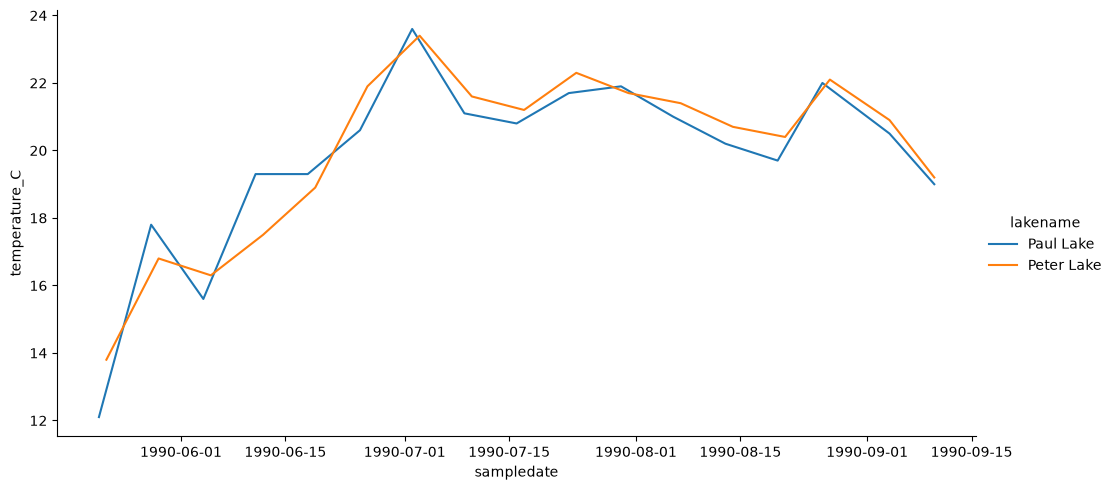

In [58]:
sns.relplot(
    data=PeterPaul_chem_nutrients.loc[
        (PeterPaul_chem_nutrients['depth']==0) &
        (PeterPaul_chem_nutrients['year4'].isin(range(1990,1991)))
    ],
    x='sampledate',
    y='temperature_C',
    aspect=2,
    kind='line',
    #hue='year4'
    hue='lakename',
    #linewidth=0.5
);

---
## Wrap-up & what's next
In this lesson, you learned how to choose an appropriate visualization based on the types of variables in your data and how to create a variety of common plots using Seaborn's figure-level interface. Rather than memorizing individual plotting functions, focus on the broader workflow: identify the question you want to answer, determine the types of variables involved, and select the plot that best communicates that information.

In the next lesson, we'll build on this foundation by learning how to customize and refine your figures. You'll explore Seaborn themes and color palettes, improve axis labels and titles, customize legends, add reference lines and annotations, and create publication-quality visualizations that communicate your results clearly and effectively.